In [1]:
# BLOCK 1 — TYPE: CODE

import numpy as np
import matplotlib.pyplot as plt

train_losses = np.load("../results/loss_data/train_losses.npy")
val_losses = np.load("../results/loss_data/val_losses.npy")


In [2]:
# BLOCK 2 — TYPE: CODE

print("Train Losses:")
for i, loss in enumerate(train_losses):
    print(f"Epoch {i+1}: {loss:.4f}")

print("\nValidation Losses:")
for i, loss in enumerate(val_losses):
    print(f"Epoch {i+1}: {loss:.4f}")


Train Losses:
Epoch 1: 0.5798
Epoch 2: 0.5229
Epoch 3: 0.4653
Epoch 4: 0.3628
Epoch 5: 0.2946

Validation Losses:
Epoch 1: 0.3403
Epoch 2: 0.3370
Epoch 3: 0.3506
Epoch 4: 0.4083
Epoch 5: 0.4091


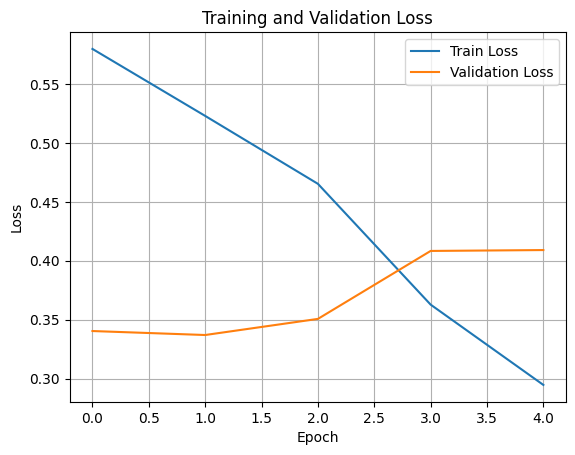

In [4]:
# BLOCK 3 — TYPE: CODE

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# BLOCK 4 — TYPE: CODE

import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

# Añadir la carpeta raíz del proyecto al path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Importar módulos internos del proyecto
from models.eegnet_transformer import EEGTransformerNet
from data.dataloader import get_dataloaders
from config.settings import (
    nclasses,
    sequence_length,
    num_eeg_channels,
    batch_size,
    device,
    data_root,
)

# Cargar modelo entrenado
model = EEGTransformerNet(
    nb_classes=nclasses,
    sequence_length=sequence_length,
    eeg_chans=num_eeg_channels,
    F1=16,
    D=2,
    eegnet_kernel_size=32,
    dropout_eegnet=0.3,
    eegnet_pooling_1=5,
    eegnet_pooling_2=5,
    MSA_num_heads=2,
    flag_positional_encoding=True,
    transformer_dim_feedforward=256,
    num_transformer_layers=1,
).to(device)

model_path = "../results/EEGTransformerNet.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
